# 01 Data Collection

This notebook downloads ETF price data, calculates daily and monthly returns, and generates basic cumulative return plots.

In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr

plt.style.use("ggplot")

print("Environment is ready.")

Environment is ready.


In [18]:
tickers = ["SPY", "QQQ", "IWM", "TLT", "GLD", "VNQ", "EFA"]

prices = pd.DataFrame()

for ticker in tickers:
    file_path = f"../data/raw/{ticker}.csv"
    df = pd.read_csv(file_path)
    
    print(ticker, df.columns.tolist())
    
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date").sort_index()
    
    df["Price"] = (
        df["Price"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .astype(float)
    )
    
    prices[ticker] = df["Price"]

prices = prices.dropna()

prices.head()

SPY ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']
QQQ ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']
IWM ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']
TLT ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']
GLD ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']
VNQ ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']
EFA ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']


,SPY,QQQ,IWM,TLT,GLD,VNQ,EFA
Date,,,,,,,
2015-01-02,205.43,102.89,118.93,127.32,114.08,82.22,60.58
2015-01-05,201.72,101.38,117.34,129.32,115.80,82.67,59.15
2015-01-06,199.82,100.02,115.31,131.65,117.12,83.49,58.48
2015-01-07,202.31,101.31,116.73,131.39,116.43,84.77,59.13
2015-01-08,205.90,103.25,118.71,129.65,115.94,85.09,59.93


In [19]:
prices.shape

(2766, 7)

In [20]:
prices.to_csv("../data/processed/prices.csv")

In [21]:
daily_returns = prices.pct_change().dropna()
daily_returns.to_csv("../data/processed/daily_returns.csv")

daily_returns.head()

,SPY,QQQ,IWM,TLT,GLD,VNQ,EFA
Date,,,,,,,
2015-01-05,-0.018060,-0.014676,-0.013369,0.015708,0.015077,0.005473,-0.023605
2015-01-06,-0.009419,-0.013415,-0.017300,0.018017,0.011399,0.009919,-0.011327
2015-01-07,0.012461,0.012897,0.012315,-0.001975,-0.005891,0.015331,0.011115
2015-01-08,0.017745,0.019149,0.016962,-0.013243,-0.004209,0.003775,0.013530
2015-01-09,-0.008014,-0.006586,-0.009603,0.010953,0.011385,0.000470,-0.004839


In [22]:
monthly_prices = prices.resample("M").last()
monthly_returns = monthly_prices.pct_change().dropna()
monthly_returns.to_csv("../data/processed/monthly_returns.csv")

monthly_returns.head()

,SPY,QQQ,IWM,TLT,GLD,VNQ,EFA
Date,,,,,,,
2015-02-28,0.056205,0.072143,0.059464,-0.063277,-0.059052,-0.036742,0.063378
2015-03-31,-0.020080,-0.025845,0.014603,0.008955,-0.021522,0.011275,-0.014286
2015-04-30,0.009834,0.019234,-0.025649,-0.036269,-0.001672,-0.058475,0.036466
2015-05-31,0.012856,0.022497,0.022363,-0.025724,0.005552,-0.003023,0.001955
2015-06-30,-0.025054,-0.027093,0.007830,-0.042784,-0.015162,-0.056229,-0.047269


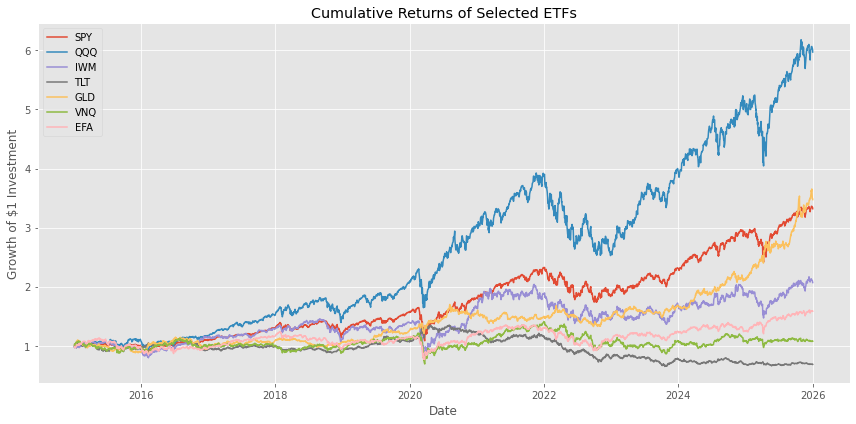

In [24]:
cumulative_returns = (1 + daily_returns).cumprod()

plt.figure(figsize=(12, 6))

x = cumulative_returns.index.to_numpy()

for ticker in tickers:
    y = cumulative_returns[ticker].to_numpy()
    plt.plot(x, y, label=ticker)

plt.title("Cumulative Returns of Selected ETFs")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig("../figures/cumulative_returns_etfs.png", dpi=300)

In [26]:
summary = pd.DataFrame({
    "Start Date": prices.index.min(),
    "End Date": prices.index.max(),
    "Observations": prices.count(),
    "Missing Values": prices.isna().sum()
})

summary

,Start Date,End Date,Observations,Missing Values
SPY,2015-01-02,2025-12-31,2766,0
QQQ,2015-01-02,2025-12-31,2766,0
IWM,2015-01-02,2025-12-31,2766,0
TLT,2015-01-02,2025-12-31,2766,0
GLD,2015-01-02,2025-12-31,2766,0
VNQ,2015-01-02,2025-12-31,2766,0
EFA,2015-01-02,2025-12-31,2766,0


In [27]:
asset_summary = pd.DataFrame({
    "Annualized Return": daily_returns.mean() * 252,
    "Annualized Volatility": daily_returns.std() * np.sqrt(252),
    "Sharpe Ratio": (daily_returns.mean() * 252) / (daily_returns.std() * np.sqrt(252))
})

asset_summary

,Annualized Return,Annualized Volatility,Sharpe Ratio
SPY,0.125363,0.178600,0.701920
QQQ,0.187123,0.219908,0.850913
IWM,0.091904,0.225698,0.407198
TLT,-0.023211,0.150533,-0.154190
GLD,0.124400,0.147473,0.843547
VNQ,0.028058,0.205600,0.136469
EFA,0.057244,0.174100,0.328796
